# **Tourism Experience Analytics**


### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported!")

✅ Libraries imported!


### Load All Datasets

In [ ]:
base_url = "https://github.com/Sabitha-23/Tourism-Analytics/raw/main/data/raw/"

transaction     = pd.read_excel(base_url + "Transaction.xlsx")
user            = pd.read_excel(base_url + "User.xlsx")
city            = pd.read_excel(base_url + "City.xlsx")
country         = pd.read_excel(base_url + "Country.xlsx")
region          = pd.read_excel(base_url + "Region.xlsx")
continent       = pd.read_excel(base_url + "Continent.xlsx")
item            = pd.read_excel(base_url + "Updated_Item.xlsx")
attraction_type = pd.read_excel(base_url + "Type.xlsx")
mode            = pd.read_excel(base_url + "Mode.xlsx")

print("✅ All datasets loaded!")

✅ All datasets loaded!


### Dataset Overview

In [ ]:
datasets = {
    "Transaction": transaction, "User": user, "City": city,
    "Country": country, "Region": region, "Continent": continent,
    "Item": item, "Type": attraction_type, "Mode": mode
}

# Shape, columns and null overview in one place
print(f"{'Table':15} {'Rows':>8} {'Cols':>6} {'Nulls':>8}")
print("-" * 42)
for name, df in datasets.items():
    print(f"{name:15} {df.shape[0]:>8} {df.shape[1]:>6} {df.isnull().sum().sum():>8}")

Table               Rows   Cols    Nulls
------------------------------------------
Transaction        52930      7        0
User               33530      5        4
City                9143      3        1
Country              165      3        0
Region                22      3        0
Continent              6      2        0
Item                1698      5        0
Type                  17      2        0
Mode                   6      2        0


### Handle Nulls

In [ ]:
# Fix City Table — drop the one row with null CityName
city_cleaned = city.dropna(subset=['CityName'])
print(f"City rows before : {len(city)}")
print(f"City rows after  : {len(city_cleaned)}")
print(f"Nulls remaining  : {city_cleaned.isnull().sum().sum()}")

# Fix User Table — fill null CityId with 0 (unknown city)
user_cleaned = user.copy()
user_cleaned['CityId'] = user_cleaned['CityId'].fillna(0).astype(int)
print(f"\nNulls before : {user['CityId'].isnull().sum()}")
print(f"Nulls after  : {user_cleaned['CityId'].isnull().sum()}")

City rows before : 9143
City rows after  : 9142
Nulls remaining  : 0

Nulls before : 4
Nulls after  : 0


### Check Duplicates

In [ ]:
print(f"{'Table':15} {'Duplicates':>12}")
print("-" * 30)
for name, df in datasets.items():
    print(f"{name:15} {df.duplicated().sum():>12}")

Table             Duplicates
------------------------------
Transaction                0
User                       0
City                       0
Country                    0
Region                     0
Continent                  0
Item                       0
Type                       0
Mode                       0


### Fix AttractionTypeId in Item Table

In [ ]:
# The AttractionTypeId column has mixed data — some rows have names, some have IDs
# Map type names to IDs using the Type table
type_name_to_id = dict(zip(attraction_type['AttractionType'], attraction_type['AttractionTypeId']))

def fix_attraction_type(val):
    try:
        return int(val)  # already a number, keep it
    except:
        return type_name_to_id.get(val, 0)  # map name to ID

item_cleaned = item.copy()
item_cleaned['AttractionTypeId'] = item['AttractionTypeId'].apply(fix_attraction_type)
item_cleaned['AttractionTypeId'] = item_cleaned['AttractionTypeId'].astype(int)

print(f"Dtype  : {item_cleaned['AttractionTypeId'].dtype}")
print(f"Nulls  : {item_cleaned['AttractionTypeId'].isnull().sum()}")
print("✅ AttractionTypeId fixed!")

Dtype  : int64
Nulls  : 0
✅ AttractionTypeId fixed!


### Check Value Ranges

=== TRANSACTION VALUE RANGES ===
VisitYear  : 2013 to 2022
VisitMonth : 1 to 12
Rating     : 1 to 5
VisitMode  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

=== RATING DISTRIBUTION ===
Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


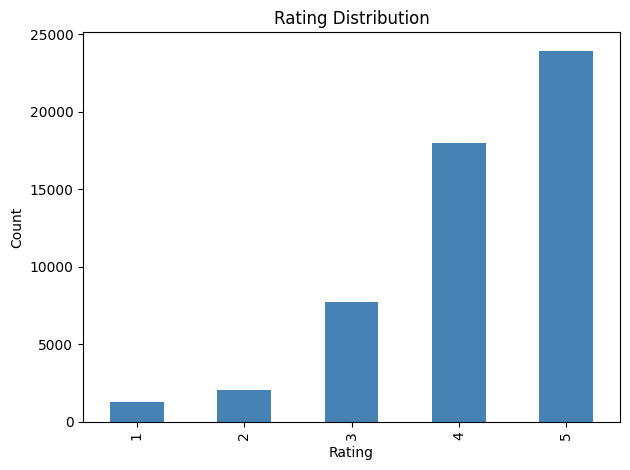

In [ ]:
print("=== TRANSACTION VALUE RANGES ===")
print(f"VisitYear  : {transaction['VisitYear'].min()} to {transaction['VisitYear'].max()}")
print(f"VisitMonth : {transaction['VisitMonth'].min()} to {transaction['VisitMonth'].max()}")
print(f"Rating     : {transaction['Rating'].min()} to {transaction['Rating'].max()}")
print(f"VisitMode  : {sorted(transaction['VisitMode'].unique())}")

print("\n=== RATING DISTRIBUTION ===")
print(transaction['Rating'].value_counts().sort_index())

transaction['Rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Save Cleaned Datasets

In [ ]:
import os

cleaned_datasets = {
    "Transaction": transaction,
    "User": user_cleaned,
    "City": city_cleaned,
    "Country": country,
    "Region": region,
    "Continent": continent,
    "Item": item_cleaned,
    "Type": attraction_type,
    "Mode": mode
}

save_path = "/content/cleaned_data/"
os.makedirs(save_path, exist_ok=True)

for name, df in cleaned_datasets.items():
    df.to_csv(f"{save_path}{name}_cleaned.csv", index=False)
    print(f"✅ {name} saved!")

✅ Transaction saved!
✅ User saved!
✅ City saved!
✅ Country saved!
✅ Region saved!
✅ Continent saved!
✅ Item saved!
✅ Type saved!
✅ Mode saved!


### Final Summary

In [ ]:
print(f"{'Table':15} {'Rows':>8} {'Cols':>6} {'Nulls':>8}")
print("-" * 45)
for name, df in cleaned_datasets.items():
    print(f"{name:15} {df.shape[0]:>8} {df.shape[1]:>6} {df.isnull().sum().sum():>8}")

print("\n✅ All datasets cleaned and saved!")

Table               Rows   Cols    Nulls
---------------------------------------------
Transaction        52930      7        0
User               33530      5        0
City                9142      3        0
Country              165      3        0
Region                22      3        0
Continent              6      2        0
Item                1698      5        0
Type                  17      2        0
Mode                   6      2        0

✅ All datasets cleaned and saved!


##  Merging & Feature Engineering

### Load Cleaned Data

In [ ]:
import pandas as pd
import numpy as np

base_path = "/content/cleaned_data/"

transaction  = pd.read_csv(base_path + "Transaction_cleaned.csv")
user         = pd.read_csv(base_path + "User_cleaned.csv")
city         = pd.read_csv(base_path + "City_cleaned.csv")
country      = pd.read_csv(base_path + "Country_cleaned.csv")
region       = pd.read_csv(base_path + "Region_cleaned.csv")
continent    = pd.read_csv(base_path + "Continent_cleaned.csv")
item         = pd.read_csv(base_path + "Item_cleaned.csv")
att_type     = pd.read_csv(base_path + "Type_cleaned.csv")
mode         = pd.read_csv(base_path + "Mode_cleaned.csv")

print("✅ All cleaned datasets loaded!")

✅ All cleaned datasets loaded!


### Merge All Tables

In [ ]:
# Step 1: Transaction + Mode (get VisitMode name)
df = transaction.merge(mode, left_on='VisitMode', right_on='VisitModeId', how='left')
df.drop(columns=['VisitModeId'], inplace=True)

# Step 2: + Item (get attraction details)
df = df.merge(item, on='AttractionId', how='left')

# Step 3: + Attraction Type (get type name)
df = df.merge(att_type, on='AttractionTypeId', how='left')

# Step 4: + User (get user demographics)
# Rename geo-ID columns immediately to avoid conflicts
df = df.merge(user, on='UserId', how='left')
df.rename(columns={
    'ContinentId': 'UserContinentId',
    'RegionId': 'UserRegionId',
    'CountryId': 'UserCountryId',
    'CityId': 'UserCityId'
}, inplace=True)

# Step 5: + City (get city name for UserCityId)
df = df.merge(city, left_on='UserCityId', right_on='CityId', how='left')
df.drop(columns=['CityId'], inplace=True)
df.rename(columns={'CountryId': 'CityCountryId'}, inplace=True)

# Step 6: + Country (get country name for UserCountryId)
df = df.merge(country, left_on='UserCountryId', right_on='CountryId', how='left')
df.drop(columns=['CountryId'], inplace=True)
df.rename(columns={'Country': 'UserCountryName', 'RegionId': 'CountryRegionId'}, inplace=True)

# Step 7: + Region (get region name for UserRegionId)
df = df.merge(region, left_on='UserRegionId', right_on='RegionId', how='left')
df.drop(columns=['RegionId'], inplace=True)
df.rename(columns={'Region': 'UserRegionName', 'ContinentId': 'RegionContinentId'}, inplace=True)

# Step 8: + Continent (get continent name for UserContinentId)
df = df.merge(continent, left_on='UserContinentId', right_on='ContinentId', how='left')
df.drop(columns=['ContinentId'], inplace=True)
df.rename(columns={'Continent': 'UserContinentName'}, inplace=True)

print(f"✅ Merged! Shape: {df.shape}")

✅ Merged! Shape: (52930, 24)


### Clean Column Names

In [ ]:
df.drop(columns=[
    'VisitMode_x', 'CityCountryId',
    'CountryRegionId', 'RegionContinentId'
], inplace=True)

df.rename(columns={
    'VisitMode_y'      : 'VisitMode',
    'UserContinentId'  : 'ContinentId',
    'UserRegionId'     : 'RegionId',
    'UserCountryId'    : 'CountryId',
    'UserCityId'       : 'CityId',
    'UserCountryName'  : 'Country',
    'UserRegionName'   : 'Region',
    'UserContinentName': 'Continent',
}, inplace=True)

print(f"✅ Columns cleaned! Shape: {df.shape}")

✅ Columns cleaned! Shape: (52930, 20)


### Feature Engineering

In [ ]:
# User-level features
df['User_Avg_Rating']  = df.groupby('UserId')['Rating'].transform('mean').round(2)
df['User_Visit_Count'] = df.groupby('UserId')['Rating'].transform('count')

# Attraction-level features
df['Attraction_Avg_Rating']  = df.groupby('AttractionId')['Rating'].transform('mean').round(2)
df['Attraction_Visit_Count'] = df.groupby('AttractionId')['Rating'].transform('count')

# Season derived from visit month
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['VisitMonth'].apply(get_season)

print("✅ Features created!")
print(f"Shape: {df.shape}")

✅ Features created!
Shape: (52930, 25)


### Save Master Dataset

In [ ]:
# Save master dataset to disk for use in later sections
df.to_csv("/content/cleaned_data/master_dataset.csv", index=False)

print("✅ Master dataset saved!")
print(f"Master dataset shape : {df.shape}")
print(f"Total columns        : {len(df.columns)}")
print(f"Total nulls          : {df.isnull().sum().sum()}")
print(f"Columns: {list(df.columns)}")
print("✅ Ready for EDA!")

✅ Master dataset saved!
Master dataset shape : (52930, 25)
Total columns        : 25
Total nulls          : 0
Columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'AttractionId', 'Rating', 'VisitMode', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'CityName', 'Country', 'Region', 'Continent', 'User_Avg_Rating', 'User_Visit_Count', 'Attraction_Avg_Rating', 'Attraction_Visit_Count', 'Season']
✅ Ready for EDA!


## EDA & Visualization

### Load Master Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/cleaned_data/master_dataset.csv")
print(f"✅ Master dataset loaded! Shape: {df.shape}")

✅ Master dataset loaded! Shape: (52930, 25)


### Rating Distribution

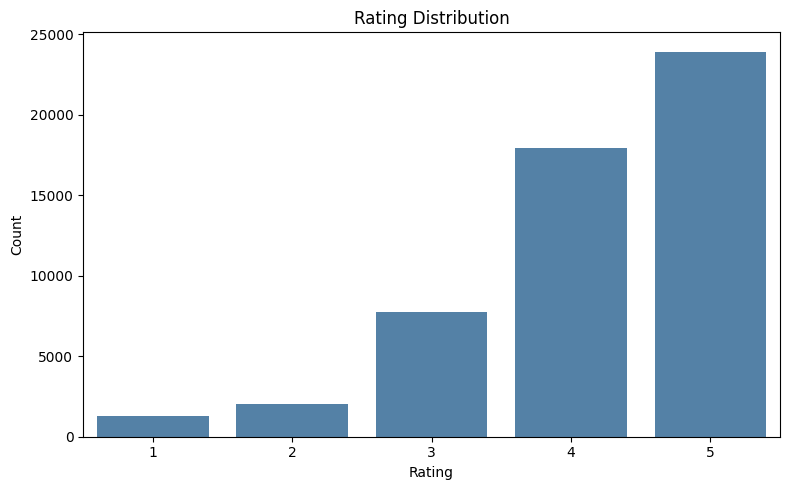

Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=df, color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['Rating'].value_counts().sort_index())

### Visit Mode Distribution

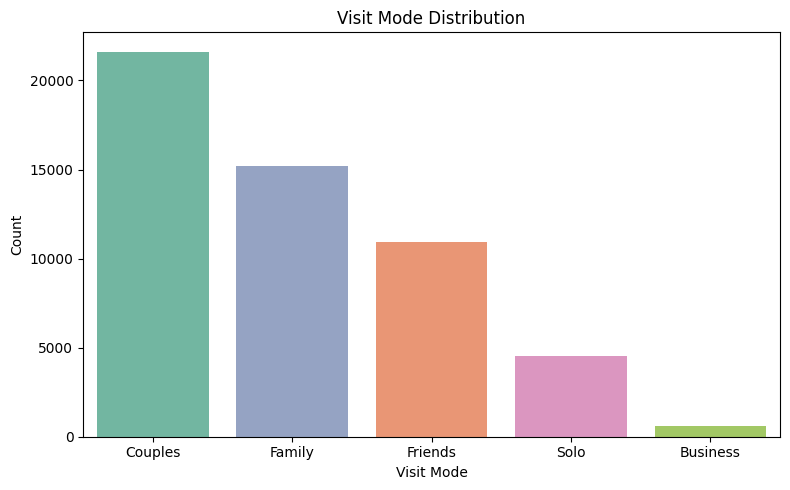

VisitMode
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='VisitMode', data=df, hue='VisitMode', legend=False,
              palette='Set2', order=df['VisitMode'].value_counts().index)
plt.title('Visit Mode Distribution')
plt.xlabel('Visit Mode')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['VisitMode'].value_counts())

### Top 10 Most Visited Attractions

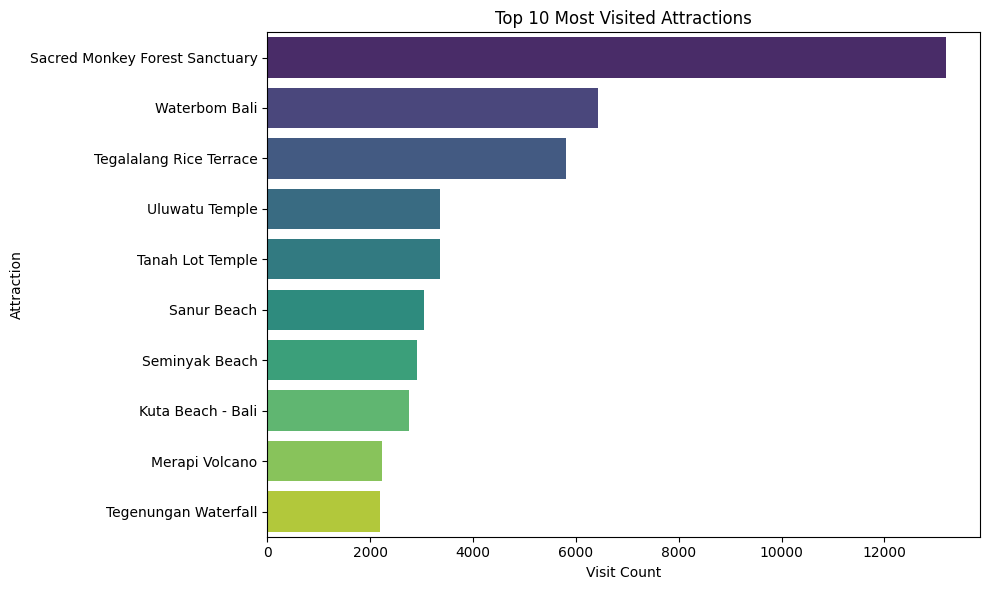

In [ ]:
plt.figure(figsize=(10,6))
top_attractions = df['Attraction'].value_counts().head(10)
sns.barplot(x=top_attractions.values, y=top_attractions.index,
            hue=top_attractions.index, legend=False, palette='viridis')
plt.title('Top 10 Most Visited Attractions')
plt.xlabel('Visit Count')
plt.tight_layout()
plt.show()

### Visits by Continent

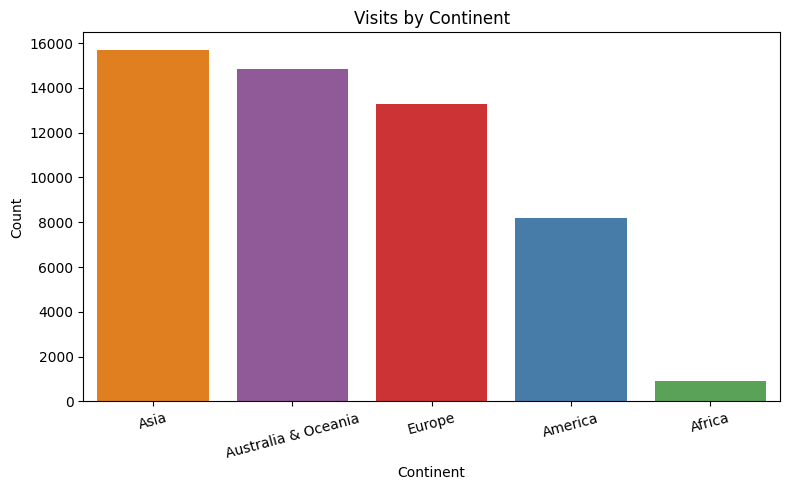

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Continent', data=df, hue='Continent', legend=False,
              palette='Set1', order=df['Continent'].value_counts().index)
plt.title('Visits by Continent')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Top 10 Countries

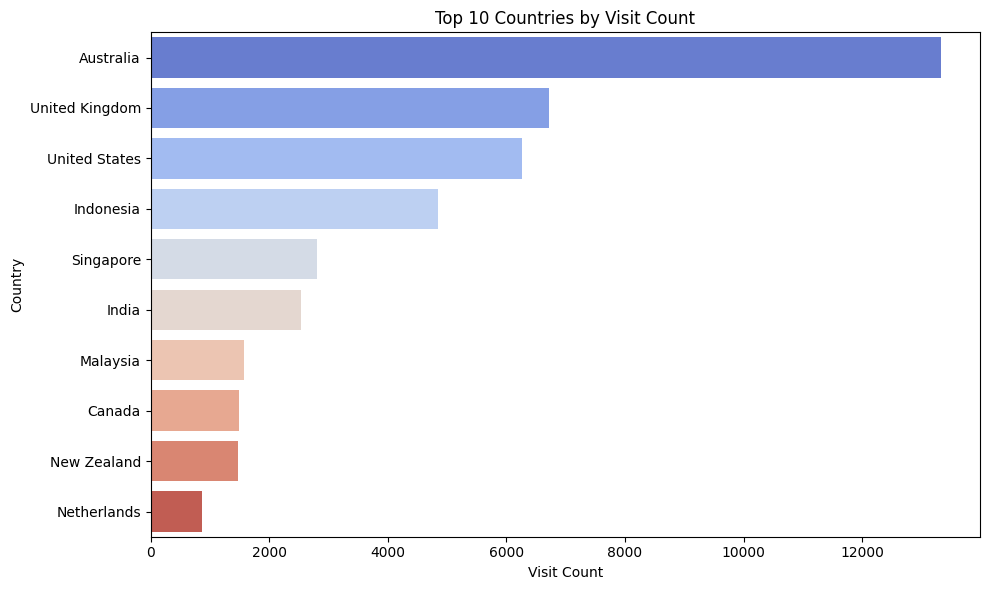

In [ ]:
plt.figure(figsize=(10,6))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index,
            hue=top_countries.index, legend=False, palette='coolwarm')
plt.title('Top 10 Countries by Visit Count')
plt.xlabel('Visit Count')
plt.tight_layout()
plt.show()

### Season vs Rating

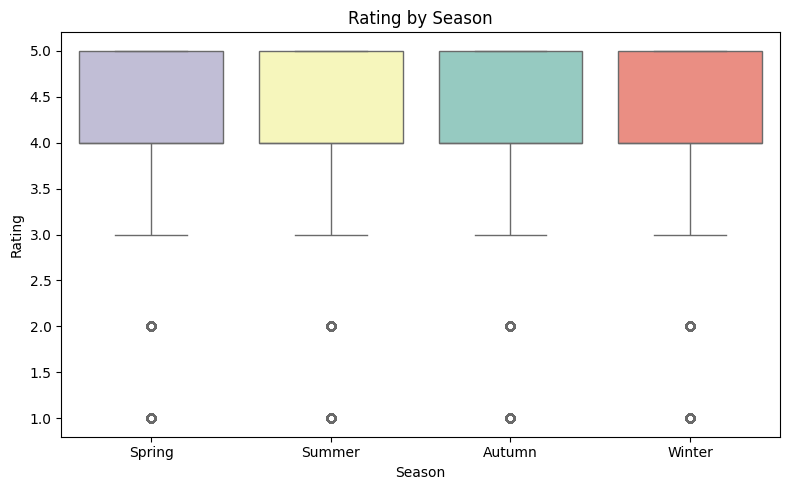

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Rating', data=df, hue='Season', legend=False,
            palette='Set3', order=['Spring','Summer','Autumn','Winter'])
plt.title('Rating by Season')
plt.tight_layout()
plt.show()

### Attraction Type Distribution

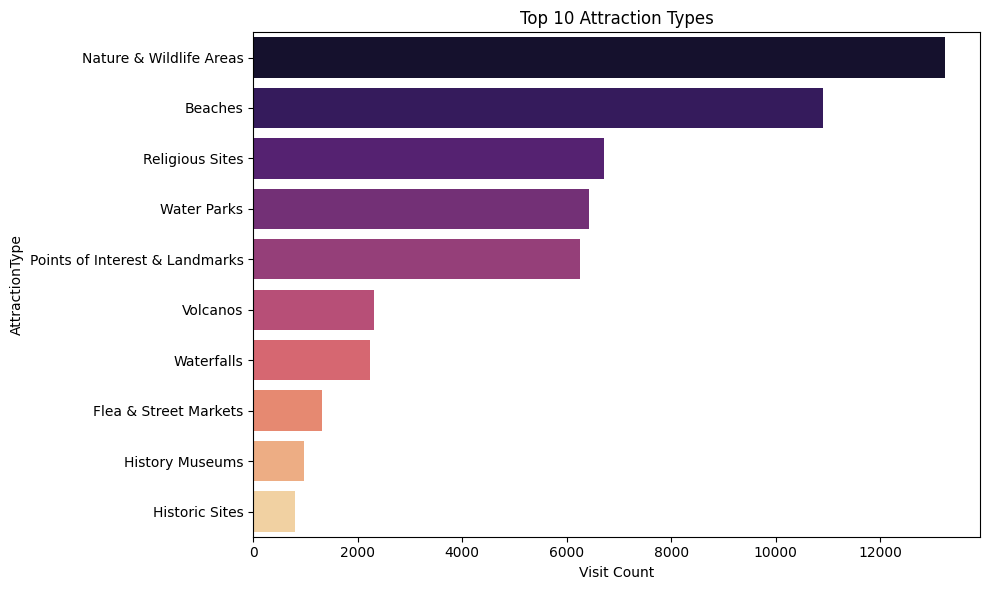

In [ ]:
plt.figure(figsize=(10,6))
top_types = df['AttractionType'].value_counts().head(10)
sns.barplot(x=top_types.values, y=top_types.index,
            hue=top_types.index, legend=False, palette='magma')
plt.title('Top 10 Attraction Types')
plt.xlabel('Visit Count')
plt.tight_layout()
plt.show()

### Correlation Heatmap

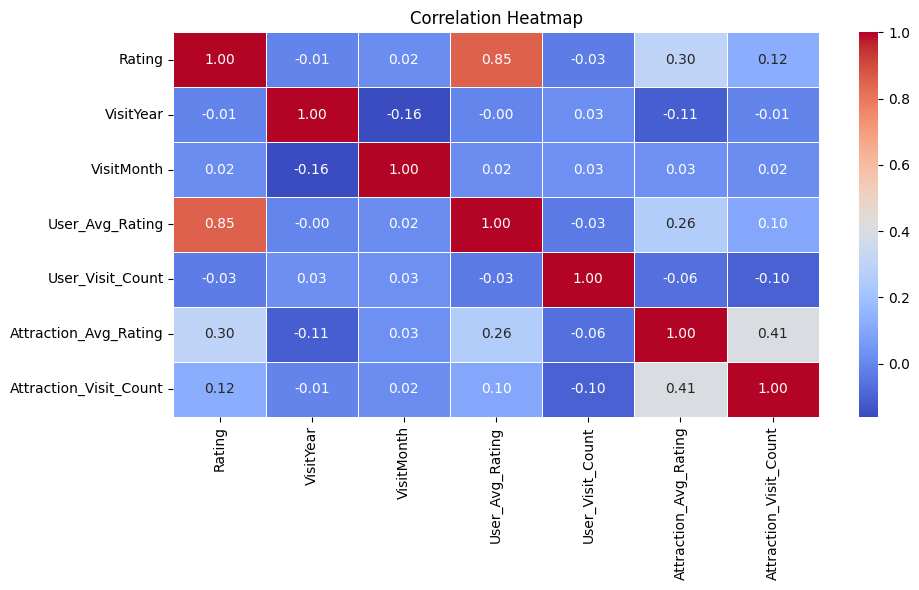

In [ ]:
plt.figure(figsize=(10,6))
num_cols = ['Rating','VisitYear','VisitMonth',
            'User_Avg_Rating','User_Visit_Count',
            'Attraction_Avg_Rating','Attraction_Visit_Count']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Regression Model (Predict Rating)

### Load Master Dataset & Select Features

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/cleaned_data/master_dataset.csv")

# Select features for regression
features = [
    'VisitYear', 'VisitMonth', 'AttractionTypeId',
    'ContinentId', 'RegionId', 'CountryId',
    'User_Avg_Rating', 'User_Visit_Count',
    'Attraction_Avg_Rating', 'Attraction_Visit_Count'
]

target = 'Rating'

X = df[features]
y = df[target]

print(f"✅ Features selected!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

✅ Features selected!
X shape: (52930, 10)
y shape: (52930,)


### Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set  : {X_train.shape}")
print(f"Testing set   : {X_test.shape}")

Training set  : (42344, 10)
Testing set   : (10586, 10)


### Train & Evaluate All Models

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"\n--- {name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return model, r2

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost"           : XGBRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    trained_model, r2 = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results[name] = (trained_model, r2)

print("\n✅ All models trained and evaluated!")


--- Linear Regression ---
MAE  : 0.2903
RMSE : 0.4972
R²   : 0.7375

--- Random Forest ---
MAE  : 0.2759
RMSE : 0.5414
R²   : 0.6888

--- XGBoost ---
MAE  : 0.2719
RMSE : 0.5020
R²   : 0.7324

✅ All models trained and evaluated!


### Pick Best Model

In [ ]:
best_name = max(results, key=lambda x: results[x][1])
best_model = results[best_name][0]

print(f"🏆 Best Model: {best_name}")
print(f"   R² Score  : {results[best_name][1]:.4f}")

🏆 Best Model: Linear Regression
   R² Score  : 0.7375


### Save Best Model

In [ ]:
import joblib
import os

best_name = max(results, key=lambda x: results[x][1])
best_model = results[best_name][0]

os.makedirs("/content/models/", exist_ok=True)
joblib.dump(best_model, "/content/models/regression_model.pkl")

print(f"✅ {best_name} saved as regression_model.pkl")

✅ Linear Regression saved as regression_model.pkl


##  Classification Model (Predict Visit Mode)

### Install & Import Libraries

In [ ]:
!pip install imbalanced-learn lightgbm -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


### Prepare Features & Target

In [ ]:
# Encode VisitMode to numeric labels
le = LabelEncoder()
df['VisitMode_Encoded'] = le.fit_transform(df['VisitMode'])

print("Visit Mode Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Select features for classification
features = [
    'VisitYear', 'VisitMonth', 'AttractionId',
    'AttractionTypeId', 'ContinentId', 'RegionId',
    'CountryId', 'Rating', 'User_Avg_Rating',
    'User_Visit_Count', 'Attraction_Avg_Rating',
    'Attraction_Visit_Count'
]

X = df[features]
y = df['VisitMode_Encoded']

print(f"\n✅ Features ready! X: {X.shape} | y: {y.shape}")

Visit Mode Encoding:
  0 → Business
  1 → Couples
  2 → Family
  3 → Friends
  4 → Solo

✅ Features ready! X: (52930, 12) | y: (52930,)


### Split & Handle Class Imbalance with SMOTE

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance minority classes in training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(le.classes_, [sum(y_train==i) for i in range(5)])))
print("After SMOTE :", dict(zip(le.classes_, [sum(y_train_bal==i) for i in range(5)])))

Before SMOTE: {'Business': 498, 'Couples': 17296, 'Family': 12174, 'Friends': 8756, 'Solo': 3620}
After SMOTE : {'Business': 17296, 'Couples': 17296, 'Family': 17296, 'Friends': 17296, 'Solo': 17296}


### Train & Evaluate All Models

In [ ]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f} | F1 Score: {f1:.4f}")
    return model, f1

models = {
    "Random Forest" : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost"       : XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    "LightGBM"      : LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

results = {}
for name, model in models.items():
    trained_model, f1 = evaluate_classifier(
        name, model, X_train_bal, X_test, y_train_bal, y_test)
    results[name] = (trained_model, f1)

print("\n✅ All models trained!")


--- Random Forest ---
Accuracy : 0.4451 | F1 Score: 0.4492

--- XGBoost ---
Accuracy : 0.4623 | F1 Score: 0.4565
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 938
[LightGBM] [Info] Number of data points in the train set: 86480, number of used features: 12
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438

--- LightGBM ---
Accuracy : 0.4590 | F1 Score: 0.4483

✅ All models trained!


### Best Model & Classification Report

In [ ]:
best_name = max(results, key=lambda x: results[x][1])
best_model = results[best_name][0]

print(f"🏆 Best Model: {best_name}")
print(f"   F1 Score  : {results[best_name][1]:.4f}")

y_pred = best_model.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

🏆 Best Model: XGBoost
   F1 Score  : 0.4565

=== Classification Report ===
              precision    recall  f1-score   support

    Business       0.07      0.31      0.12       125
     Couples       0.52      0.64      0.57      4324
      Family       0.53      0.46      0.49      3043
     Friends       0.38      0.24      0.30      2189
        Solo       0.22      0.18      0.20       905

    accuracy                           0.46     10586
   macro avg       0.35      0.37      0.34     10586
weighted avg       0.47      0.46      0.46     10586



### Save Best Model & Encoder

In [ ]:
import joblib
import os

os.makedirs("/content/models/", exist_ok=True)
joblib.dump(best_model, "/content/models/classification_model.pkl")
joblib.dump(le, "/content/models/label_encoder.pkl")

print(f"✅ {best_name} saved as classification_model.pkl")
print("✅ Label encoder saved as label_encoder.pkl")

✅ XGBoost saved as classification_model.pkl
✅ Label encoder saved as label_encoder.pkl


##  Recommendation System

### Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Reload master dataset fresh to avoid any column conflicts from previous sections
df = pd.read_csv("/content/cleaned_data/master_dataset.csv")

print("✅ Libraries imported!")
print(f"Dataset shape: {df.shape}")

✅ Libraries imported!
Dataset shape: (52930, 25)


### Build User-Item Matrix

In [ ]:
# Create a matrix where rows = users, columns = attractions, values = ratings
user_item_matrix = df.pivot_table(
    index='UserId',
    columns='AttractionId',
    values='Rating'
).fillna(0)

print(f"User-Item Matrix Shape: {user_item_matrix.shape}")
print(f"Users: {user_item_matrix.shape[0]} | Attractions: {user_item_matrix.shape[1]}")

User-Item Matrix Shape: (33530, 30)
Users: 33530 | Attractions: 30


### Compute User & Attraction Similarities

In [ ]:
# Compute cosine similarity between users
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

# Build attraction feature matrix for content-based filtering
attraction_features = df[[
    'AttractionId', 'AttractionTypeId',
    'Attraction_Avg_Rating', 'Attraction_Visit_Count'
]].drop_duplicates('AttractionId').set_index('AttractionId')

# Normalize features to same scale
scaler = MinMaxScaler()
attraction_features_scaled = pd.DataFrame(
    scaler.fit_transform(attraction_features),
    index=attraction_features.index,
    columns=attraction_features.columns
)

# Compute cosine similarity between attractions
attraction_similarity = cosine_similarity(attraction_features_scaled)
attraction_similarity_df = pd.DataFrame(
    attraction_similarity,
    index=attraction_features.index,
    columns=attraction_features.index
)

print("✅ User & Attraction similarity computed!")

✅ User & Attraction similarity computed!


### Collaborative Filtering Function

In [ ]:
def collaborative_filtering(user_id, n_recommendations=5):
    # Check if user exists in our matrix
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found!"

    # Find top 50 most similar users based on cosine similarity
    similar_users = user_similarity_df[user_id]\
        .sort_values(ascending=False)[1:51].index.tolist()

    # Get attractions already visited by this user
    visited = set(df[df['UserId'] == user_id]['AttractionId'].values)

    # Collect ratings given by similar users for unvisited attractions
    recommendations = {}
    for sim_user in similar_users:
        sim_attractions = df[df['UserId'] == sim_user]\
            .groupby('AttractionId')['Rating'].mean()
        for attraction_id, rating in sim_attractions.items():
            if attraction_id not in visited:
                if attraction_id not in recommendations:
                    recommendations[attraction_id] = []
                recommendations[attraction_id].append(rating)

    # Fallback — if no new attractions found, recommend top rated overall
    if not recommendations:
        top_attractions = df.groupby('AttractionId')['Rating']\
            .mean().sort_values(ascending=False)
        top_attractions = top_attractions[
            ~top_attractions.index.isin(visited)
        ].head(n_recommendations)
        attraction_names = df[['AttractionId','Attraction','AttractionType']]\
            .drop_duplicates('AttractionId')
        rec_df = pd.DataFrame({
            'AttractionId': top_attractions.index,
            'Rating': top_attractions.values
        }).merge(attraction_names, on='AttractionId')
        return rec_df[['Attraction','AttractionType','Rating']]

    # Rank unvisited attractions by average rating from similar users
    rec_df = pd.DataFrame([
        {'AttractionId': k, 'Rating': np.mean(v)}
        for k, v in recommendations.items()
    ]).sort_values('Rating', ascending=False).head(n_recommendations)

    # Add attraction names and types
    attraction_names = df[['AttractionId','Attraction','AttractionType']]\
        .drop_duplicates('AttractionId')
    rec_df = rec_df.merge(attraction_names, on='AttractionId')

    return rec_df[['Attraction','AttractionType','Rating']]

### Content Based Filtering Function

In [ ]:
def content_based_filtering(user_id, n_recommendations=5):
    # Get all attractions visited by this user with their average ratings
    user_visited = df[df['UserId'] == user_id]\
        .groupby('AttractionId')['Rating'].mean()

    if user_visited.empty:
        return f"User {user_id} not found!"

    # Find attractions not yet visited by this user
    visited_ids = user_visited.index.tolist()
    not_visited = [a for a in attraction_similarity_df.index
                   if a not in visited_ids]

    if not not_visited:
        return "User has visited all attractions!"

    # Score each unvisited attraction based on similarity
    # to all attractions the user has visited, weighted by their rating
    scores = {}
    for attraction in not_visited:
        sim_scores = []
        for visited_id in visited_ids:
            if visited_id in attraction_similarity_df.index:
                # similarity score × user rating = weighted score
                sim = attraction_similarity_df.loc[visited_id, attraction]
                user_rating = user_visited[visited_id]
                sim_scores.append(sim * user_rating)
        scores[attraction] = np.mean(sim_scores) if sim_scores else 0

    # Rank by score and get top recommendations
    rec_df = pd.DataFrame([
        {'AttractionId': k, 'Score': v}
        for k, v in scores.items()
    ]).sort_values('Score', ascending=False).head(n_recommendations)

    # Add attraction details
    attraction_names = df[['AttractionId','Attraction',
                           'AttractionType','Attraction_Avg_Rating']]\
        .drop_duplicates('AttractionId')
    rec_df = rec_df.merge(attraction_names, on='AttractionId')

    return rec_df[['Attraction','AttractionType','Attraction_Avg_Rating','Score']]

### Hybrid Recommendation & Test

In [ ]:
def hybrid_recommendation(user_id, n_recommendations=5):
    print(f"\n{'='*50}")
    print(f"  Recommendations for User {user_id}")
    print(f"{'='*50}")
    print("\n📌 Collaborative Filtering:")
    print(collaborative_filtering(user_id, n_recommendations))
    print("\n📌 Content Based Filtering:")
    print(content_based_filtering(user_id, n_recommendations))

# Test with a sample user from the matrix
sample_user = user_item_matrix.index[0]
hybrid_recommendation(sample_user)


  Recommendations for User 14

📌 Collaborative Filtering:
                           Attraction   AttractionType    Rating
0                Mount Semeru Volcano         Volcanos  4.698795
1                       Waterbom Bali      Water Parks  4.646601
2  Bromo Tengger Semeru National Park   National Parks  4.611549
3     Khayangan Reflexology & Massage             Spas  4.571429
4                       Jomblang Cave  Caverns & Caves  4.503704

📌 Content Based Filtering:
         Attraction         AttractionType  Attraction_Avg_Rating     Score
0     Waterbom Bali            Water Parks                   4.65  4.250867
1  Tanah Lot Temple        Religious Sites                   4.19  4.127980
2    Uluwatu Temple        Religious Sites                   4.22  4.126957
3    Seminyak Beach                Beaches                   3.80  4.059738
4    Malioboro Road  Flea & Street Markets                   3.87  4.039232


### Save All Components

In [ ]:
import joblib
import os

os.makedirs("/content/models/", exist_ok=True)

# Save user-item matrix and attraction similarity (skip user_similarity_df — too large)
joblib.dump(user_item_matrix, "/content/models/user_item_matrix.pkl")
joblib.dump(attraction_similarity_df, "/content/models/attraction_similarity.pkl")
joblib.dump(scaler, "/content/models/rec_scaler.pkl")

print("✅ All recommendation components saved!")
print(f"user_item_matrix     : {user_item_matrix.shape}")
print(f"attraction_similarity: {attraction_similarity_df.shape}")

✅ All recommendation components saved!
user_item_matrix     : (33530, 30)
attraction_similarity: (30, 30)


🌐 App: https://tourism-analytics-lspgujljb57fg6tfgdkxtg.streamlit.app/

📁 GitHub: github.com/Sabitha-23/tourism-analytics
